In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from google.colab import files

In [7]:
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df  = pd.read_csv('fashion-mnist_test.csv')
print(train_df.shape, test_df.shape)
print(train_df.head())


(2839, 785) (8987, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
1       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
2       0  ...       0.0       0.0       0.0      30.0      43.0       0.0   
3       0  ...       3.0       0.0       0.0       0.0       0.0       1.0   
4       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   

   pixel781  pixel782  pixel783  pixel784  
0     

In [9]:
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values
X_test  = test_df.drop('label', axis=1).values
y_test  = test_df['label'].values
print(X_train.shape, X_test.shape)

(2839, 784) (8987, 784)


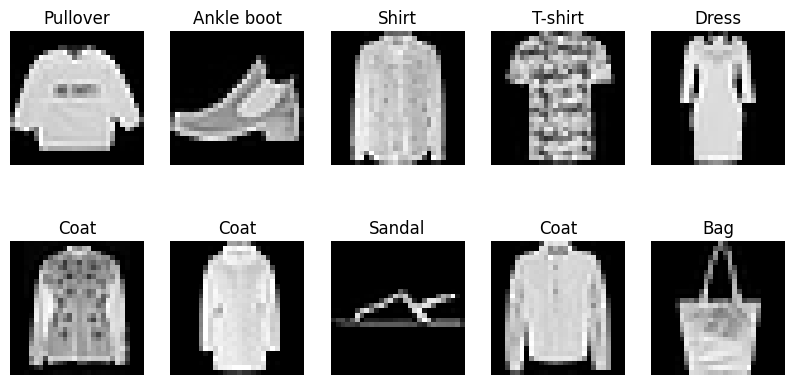

In [10]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [13]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test,  10)
print(X_train.shape, y_train_cat.shape)

(2839, 28, 28, 1) (2839, 10)


In [15]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
history = model.fit(X_train, y_train_cat, epochs=15, batch_size=64, validation_split=0.1, verbose=1)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.1014 - loss: 2.3031 - val_accuracy: 0.1056 - val_loss: nan
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1080 - loss: 2.3025 - val_accuracy: 0.0986 - val_loss: nan
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1108 - loss: 2.3023 - val_accuracy: 0.0986 - val_loss: nan
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0947 - loss: 2.3022 - val_accuracy: 0.1056 - val_loss: nan
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1072 - loss: 2.3019 - val_accuracy: 0.1056 - val_loss: nan
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.1104 - loss: 2.3018 - val_accuracy: 0.1056 - val_loss: nan
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1072 - loss: 2.3018 - val_accuracy: 0.1056 - val_loss: nan
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1065 - loss: 2.3021 - val_accuracy: 0.0986 - val_loss: nan
Epoch 9/

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss    : nan
Test Accuracy: 0.0985


In [21]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

for i in range(10):
    actual    = class_names[y_test[i]]
    predicted = class_names[y_pred[i]]
    correct   = "✅" if y_test[i] == y_pred[i] else "❌"
    print(f"Actual: {actual:15} Predicted: {predicted:15} {correct}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Actual: T-shirt         Predicted: Sneaker         ❌
Actual: Trouser         Predicted: Sneaker         ❌
Actual: Pullover        Predicted: Sneaker         ❌
Actual: Pullover        Predicted: Sneaker         ❌
Actual: Dress           Predicted: Sneaker         ❌
Actual: Pullover        Predicted: Sneaker         ❌
Actual: Bag             Predicted: Sneaker         ❌
Actual: Shirt           Predicted: Sneaker         ❌
Actual: Sandal          Predicted: Sneaker         ❌
Actual: T-shirt         Predicted: Sneaker         ❌


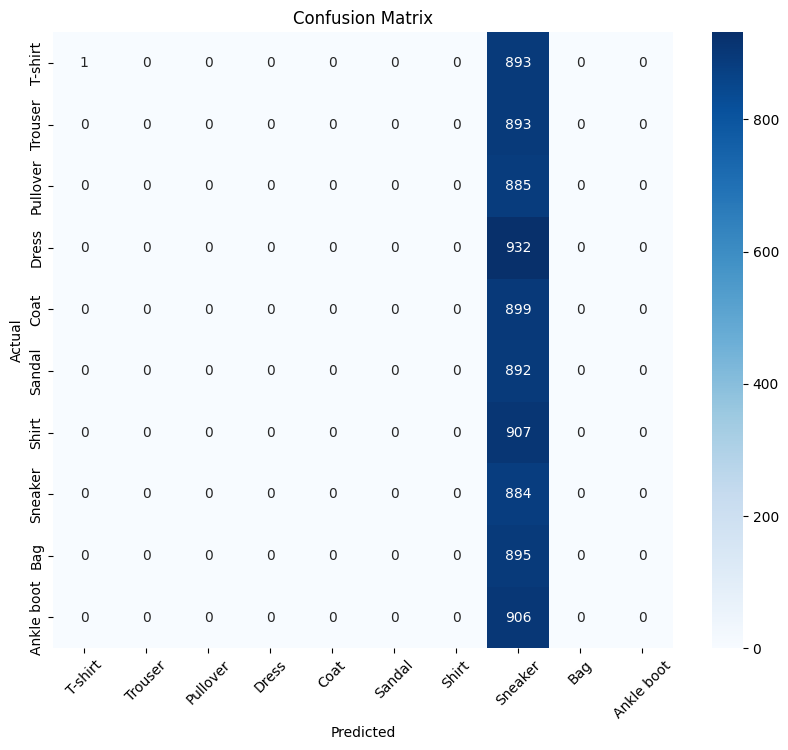

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.show()

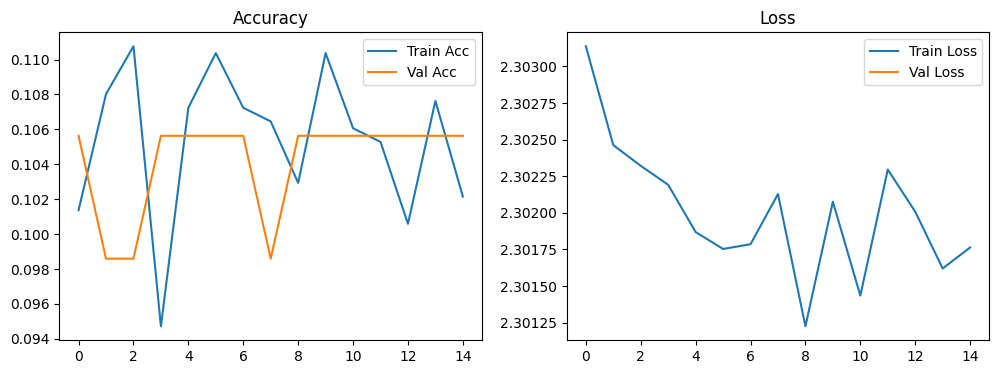

In [24]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

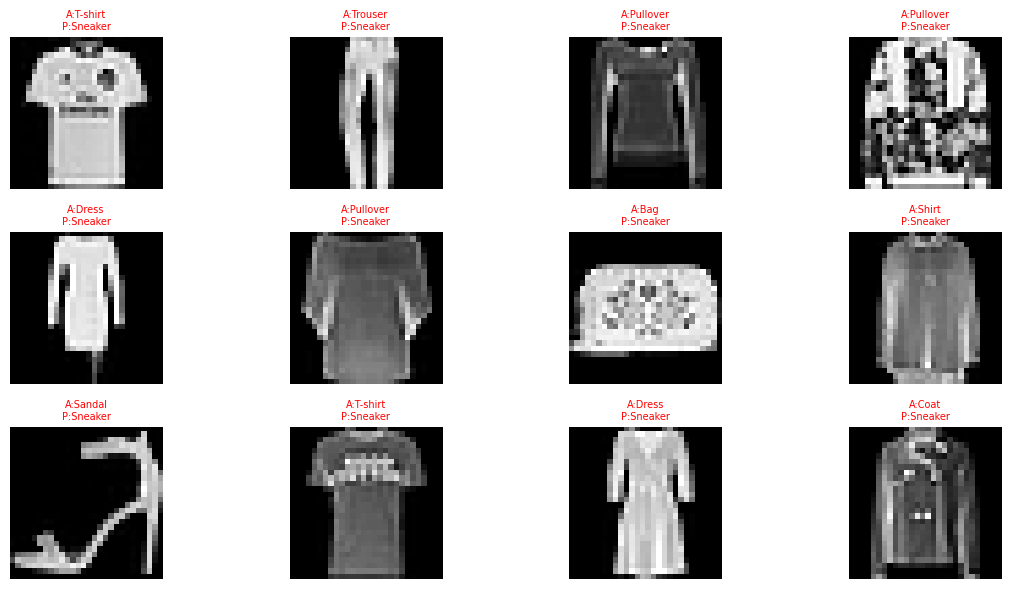

In [25]:
plt.figure(figsize=(12,6))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    actual    = class_names[y_test[i]]
    predicted = class_names[y_pred[i]]
    color = 'green' if y_test[i] == y_pred[i] else 'red'
    plt.title(f"A:{actual}\nP:{predicted}", color=color, fontsize=7)
    plt.axis('off')
plt.tight_layout()
plt.show()